# 15 · 토스 세그먼트와 모델링 준비도 감사

**한 줄 답:** 첫 10분/이후 24시간 라벨은 시간 누수 없이 만들 수 있지만, 현재 46대·양성 8대라 모델 학습이 아니라 세그먼트별 표본 적정성 감사에서 멈춘다.

**게이트:** G3 보강. 표본·라벨·세그먼트·기기 단위 후보표가 재실행 가능하고, 경계 위반이 0이며, 모델링으로 넘어가기 전 부족한 양성 수와 오염 위험을 문서화하면 통과다. AUC·피처 중요도·모델 학습은 이 노트북 범위 밖이다.

**이전 노트북과의 연결:** 14번은 시간 경계와 라벨 분포만 확인했다. 이 노트북은 같은 정의를 기기 단위 후보표와 세그먼트 준비도 표로 확장한다.

## 1. 범위와 금지선

- 원천은 BigQuery GA4 일별 export 2026-09-04~09-12(KST)다. `platform='toss'` 이벤트가 처음 관측된 기기를 대상으로 한다.
- 첫 토스 이벤트부터 10분 미만은 피처 구간, 10분 이후 24시간 미만은 임시 라벨 구간이다. 24시간 관측이 완전하지 않은 기기는 제외한다.
- `beta_A/B` 표식 기기는 제외한다. 다만 미표식 내부 사용자까지 배제됐다는 증거는 없다.
- `user_pseudo_id`는 쿼리 내부에서만 묶는다. 저장 결과에는 `D001` 같은 익명 행 라벨만 남긴다.
- 자동 수집·로그인·경제 장부·`tutorial_skip`은 의도적 행동에서 제외한다.
- 이번 노트북은 모델을 학습하지 않는다. 모델링 후보표가 만들어져도 G4 베이스라인 승인 전에는 쓰지 않는다.

In [1]:
from pathlib import Path
import json
import os, sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))

from calm_ml import bq, report as R

R.setup()
SQL_DEVICE = ROOT / 'ml/sql/g3_toss_device_feature_candidate.sql'
SQL_SEGMENT = ROOT / 'ml/sql/g3_toss_segment_modeling_readiness.sql'
OUT = ROOT / 'ml/reports/g3_toss_segment_readiness_2026-09-15'
OUT.mkdir(parents=True, exist_ok=True)

def wilson(k, n, z=1.96):
    if n == 0:
        return 0, 0
    p = k / n
    den = 1 + z * z / n
    center = (p + z * z / (2 * n)) / den
    half = z * ((p * (1 - p) / n + z * z / (4 * n * n)) ** 0.5) / den
    return center - half, center + half


## 2. 실행 SQL

첫 SQL은 다음 모델링 게이트에서 쓸 수 있는 **익명 기기 단위 후보표**를 만든다. 두 번째 SQL은 같은 표본을 세그먼트별로 집계해 표본 수와 양성 수를 확인한다.

In [2]:
display(Markdown('### 기기 단위 후보표 SQL\n```sql\n' + SQL_DEVICE.read_text(encoding='utf-8') + '\n```'))
display(Markdown('### 세그먼트 준비도 SQL\n```sql\n' + SQL_SEGMENT.read_text(encoding='utf-8') + '\n```'))


### 기기 단위 후보표 SQL
```sql
-- G3 candidate device-level table for offline modeling readiness, NOT a model.
-- Cohort: GA4 devices with platform='toss', first seen 2026-09-04..09-11 KST,
-- beta_A/B marker absent, and a complete 24h label window in daily exports.
-- Feature window: [first_toss_ts, +10m). Candidate label: [+10m, +24h).
-- Only anonymous row labels leave BigQuery; user_pseudo_id is an internal key.
-- Automatic GA4 events, login bookkeeping, economy bookkeeping, and tutorial_skip
-- are not deliberate play actions.
WITH actions AS (
  SELECT action_name, area FROM UNNEST([
    STRUCT('chop_tree' AS action_name, 'nature' AS area),
    ('first_chop', 'nature'),
    ('plant_seed', 'nature'),
    ('water_crop', 'nature'),
    ('harvest_crop', 'nature'),
    ('forage_pick', 'nature'),
    ('mine_ore', 'nature'),
    ('fishing_cast', 'fishing_sea'),
    ('fishing_catch', 'fishing_sea'),
    ('fishing_miss', 'fishing_sea'),
    ('sea_cast', 'fishing_sea'),
    ('sea_catch', 'fishing_sea'),
    ('boat_start', 'fishing_sea'),
    ('npc_talk', 'quest_social'),
    ('quest_accept', 'quest_social'),
    ('quest_complete', 'quest_social'),
    ('gift_give', 'quest_social'),
    ('shop_sell', 'craft_home'),
    ('shop_buy', 'craft_home'),
    ('craft_item', 'craft_home'),
    ('place_decor', 'craft_home'),
    ('house_complete', 'craft_home'),
    ('house_expand', 'craft_home'),
    ('cooking_start', 'craft_home'),
    ('carve_start', 'craft_home'),
    ('mist_purify_start', 'advanced'),
    ('firefly_swing', 'advanced'),
    ('coop_build', 'advanced'),
    ('coop_feed', 'advanced'),
    ('coop_collect', 'advanced'),
    ('cafe_serve', 'advanced'),
    ('photo_capture', 'advanced'),
    ('dex_open', 'advanced'),
    ('album_open', 'advanced'),
    ('leaderboard_open', 'advanced')
  ])
),
base AS (
  SELECT
    user_pseudo_id,
    TIMESTAMP_MICROS(event_timestamp) AS ts,
    DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS day,
    event_name,
    device.category AS device,
    geo.country AS country,
    traffic_source.source AS acquisition_source,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'platform' LIMIT 1) AS platform,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'method' LIMIT 1) AS login_method,
    (SELECT ep.value.string_value FROM UNNEST(event_params) ep
      WHERE ep.key = 'result' LIMIT 1) AS connect_result,
    (SELECT up.value.string_value FROM UNNEST(user_properties) up
      WHERE up.key = 'ab_variant' LIMIT 1) AS ab_variant
  FROM `calm-forest.analytics_547127440.events_*`
  WHERE _TABLE_SUFFIX NOT LIKE 'intraday_%'
    AND _TABLE_SUFFIX BETWEEN '20260904' AND '20260912'
    AND user_pseudo_id IS NOT NULL
),
toss AS (
  SELECT * FROM base WHERE platform = 'toss'
),
first_seen AS (
  SELECT
    user_pseudo_id,
    MIN(ts) AS first_ts,
    MIN(day) AS first_toss_day,
    LOGICAL_OR(REGEXP_CONTAINS(COALESCE(ab_variant, ''), r'^beta_[AB]$')) AS beta_marked
  FROM toss
  GROUP BY 1
),
eligible AS (
  SELECT *
  FROM first_seen
  WHERE NOT beta_marked
    AND first_ts < TIMESTAMP_SUB(TIMESTAMP('2026-09-13 00:00:00', 'Asia/Seoul'), INTERVAL 24 HOUR)
),
events AS (
  SELECT
    t.*,
    e.first_ts,
    e.first_toss_day,
    CASE
      WHEN t.ts >= e.first_ts
       AND t.ts < TIMESTAMP_ADD(e.first_ts, INTERVAL 10 MINUTE) THEN 'feature'
      WHEN t.ts >= TIMESTAMP_ADD(e.first_ts, INTERVAL 10 MINUTE)
       AND t.ts < TIMESTAMP_ADD(e.first_ts, INTERVAL 24 HOUR) THEN 'label'
      ELSE 'outside'
    END AS window_name
  FROM toss t
  JOIN eligible e USING (user_pseudo_id)
),
features AS (
  SELECT
    user_pseudo_id,
    first_ts,
    first_toss_day,
    ARRAY_AGG(STRUCT(
      COALESCE(device, '(unknown)') AS device,
      CASE
        WHEN country = 'South Korea' THEN 'South Korea'
        WHEN country = 'United States' THEN 'United States'
        WHEN country IS NULL THEN '(unknown)'
        ELSE 'Other'
      END AS country_group,
      COALESCE(acquisition_source, '(direct)') AS acquisition_source
    ) ORDER BY ts LIMIT 1)[OFFSET(0)] AS profile,
    COUNTIF(window_name = 'feature') AS early_tracked_events,
    COUNTIF(window_name = 'feature' AND event_name IN (SELECT action_name FROM actions)) AS early_actions,
    COUNT(DISTINCT IF(window_name = 'feature' AND event_name IN (SELECT action_name FROM actions),
      event_name, NULL)) AS early_action_kinds,
    COUNT(DISTINCT IF(window_name = 'feature' AND event_name IN (SELECT action_name FROM actions),
      (SELECT area FROM actions WHERE action_name = event_name), NULL)) AS early_area_count,
    COUNTIF(window_name = 'feature' AND event_name IN (
      SELECT action_name FROM actions WHERE area = 'nature'
    )) AS early_nature_events,
    COUNTIF(window_name = 'feature' AND event_name IN (
      SELECT action_name FROM actions WHERE area = 'fishing_sea'
    )) AS early_fishing_sea_events,
    COUNTIF(window_name = 'feature' AND event_name IN (
      SELECT action_name FROM actions WHERE area = 'quest_social'
    )) AS early_quest_social_events,
    COUNTIF(window_name = 'feature' AND event_name IN (
      SELECT action_name FROM actions WHERE area = 'craft_home'
    )) AS early_craft_home_events,
    COUNTIF(window_name = 'feature' AND event_name IN (
      SELECT action_name FROM actions WHERE area = 'advanced'
    )) AS early_advanced_events,
    COUNTIF(window_name = 'feature' AND event_name = 'toss_connect' AND connect_result = 'fail') AS early_connect_fail,
    COUNTIF(window_name = 'feature' AND event_name = 'toss_connect' AND connect_result = 'ok') AS early_connect_ok,
    COUNTIF(window_name = 'feature' AND event_name = 'login' AND login_method = 'toss') AS early_toss_login,
    COUNTIF(window_name = 'feature' AND event_name = 'login_screen') AS early_login_screen,
    COUNTIF(window_name = 'feature' AND event_name = 'tutorial_start') AS early_tutorial_start,
    COUNTIF(window_name = 'feature' AND event_name = 'tutorial_complete') AS early_tutorial_complete,
    COUNTIF(window_name = 'label' AND event_name IN (SELECT action_name FROM actions)) AS later_actions,
    COUNT(DISTINCT IF(window_name = 'label' AND event_name IN (SELECT action_name FROM actions),
      event_name, NULL)) AS later_action_kinds,
    COUNT(DISTINCT IF(window_name = 'label' AND event_name IN (SELECT action_name FROM actions),
      (SELECT area FROM actions WHERE action_name = event_name), NULL)) AS later_area_count,
    MAX(IF(window_name = 'feature' AND event_name IN (SELECT action_name FROM actions), ts, NULL)) AS last_feature_action_ts,
    MIN(IF(window_name = 'label' AND event_name IN (SELECT action_name FROM actions), ts, NULL)) AS first_label_action_ts
  FROM events
  GROUP BY 1, 2, 3
)
SELECT
  FORMAT('D%03d', ROW_NUMBER() OVER (ORDER BY FARM_FINGERPRINT(user_pseudo_id))) AS device_label,
  first_toss_day,
  profile.device AS device,
  profile.country_group AS country_group,
  profile.acquisition_source AS acquisition_source,
  early_tracked_events,
  early_actions,
  early_action_kinds,
  early_area_count,
  early_nature_events,
  early_fishing_sea_events,
  early_quest_social_events,
  early_craft_home_events,
  early_advanced_events,
  early_connect_fail,
  early_connect_ok,
  early_toss_login,
  early_login_screen,
  early_tutorial_start,
  early_tutorial_complete,
  later_actions,
  later_action_kinds,
  later_area_count,
  later_actions > 0 AS later_active,
  CASE WHEN early_actions = 0 THEN '0회'
       WHEN early_actions BETWEEN 1 AND 5 THEN '1~5회'
       ELSE '6회 이상' END AS early_action_segment,
  CASE WHEN early_area_count = 0 THEN '0개'
       WHEN early_area_count = 1 THEN '1개'
       ELSE '2개 이상' END AS early_area_segment,
  CASE
    WHEN early_connect_fail > 0 THEN '연결 실패 기록'
    WHEN early_connect_ok > 0 THEN '연결 성공만 기록'
    ELSE '연결 이벤트 없음'
  END AS early_connection_segment,
  COUNTIF(last_feature_action_ts >= TIMESTAMP_ADD(first_ts, INTERVAL 10 MINUTE)) AS feature_boundary_violations,
  COUNTIF(first_label_action_ts < TIMESTAMP_ADD(first_ts, INTERVAL 10 MINUTE)) AS label_boundary_violations
FROM features
GROUP BY
  user_pseudo_id, first_toss_day, device, country_group, acquisition_source,
  early_tracked_events, early_actions, early_action_kinds, early_area_count,
  early_nature_events, early_fishing_sea_events, early_quest_social_events,
  early_craft_home_events, early_advanced_events, early_connect_fail,
  early_connect_ok, early_toss_login, early_login_screen, early_tutorial_start,
  early_tutorial_complete, later_actions, later_action_kinds, later_area_count,
  later_active, early_action_segment, early_area_segment, early_connection_segment
ORDER BY device_label;

```

### 세그먼트 준비도 SQL
```sql
-- G3 aggregate segment readiness audit for the Toss early/later candidate label.
-- This query wraps g3_toss_device_feature_candidate.sql conceptually, but is
-- kept standalone so BigQuery can run it directly from a file.
-- Output is aggregate only: no raw identifiers, no exact timestamps.
WITH device_rows AS (
  -- Keep this CTE in sync with ml/sql/g3_toss_device_feature_candidate.sql.
  WITH actions AS (
    SELECT action_name, area FROM UNNEST([
      STRUCT('chop_tree' AS action_name, 'nature' AS area),
      ('first_chop', 'nature'), ('plant_seed', 'nature'), ('water_crop', 'nature'),
      ('harvest_crop', 'nature'), ('forage_pick', 'nature'), ('mine_ore', 'nature'),
      ('fishing_cast', 'fishing_sea'), ('fishing_catch', 'fishing_sea'),
      ('fishing_miss', 'fishing_sea'), ('sea_cast', 'fishing_sea'),
      ('sea_catch', 'fishing_sea'), ('boat_start', 'fishing_sea'),
      ('npc_talk', 'quest_social'), ('quest_accept', 'quest_social'),
      ('quest_complete', 'quest_social'), ('gift_give', 'quest_social'),
      ('shop_sell', 'craft_home'), ('shop_buy', 'craft_home'),
      ('craft_item', 'craft_home'), ('place_decor', 'craft_home'),
      ('house_complete', 'craft_home'), ('house_expand', 'craft_home'),
      ('cooking_start', 'craft_home'), ('carve_start', 'craft_home'),
      ('mist_purify_start', 'advanced'), ('firefly_swing', 'advanced'),
      ('coop_build', 'advanced'), ('coop_feed', 'advanced'),
      ('coop_collect', 'advanced'), ('cafe_serve', 'advanced'),
      ('photo_capture', 'advanced'), ('dex_open', 'advanced'),
      ('album_open', 'advanced'), ('leaderboard_open', 'advanced')
    ])
  ),
  base AS (
    SELECT
      user_pseudo_id,
      TIMESTAMP_MICROS(event_timestamp) AS ts,
      DATE(TIMESTAMP_MICROS(event_timestamp), 'Asia/Seoul') AS day,
      event_name,
      device.category AS device,
      geo.country AS country,
      traffic_source.source AS acquisition_source,
      (SELECT ep.value.string_value FROM UNNEST(event_params) ep
        WHERE ep.key = 'platform' LIMIT 1) AS platform,
      (SELECT ep.value.string_value FROM UNNEST(event_params) ep
        WHERE ep.key = 'method' LIMIT 1) AS login_method,
      (SELECT ep.value.string_value FROM UNNEST(event_params) ep
        WHERE ep.key = 'result' LIMIT 1) AS connect_result,
      (SELECT up.value.string_value FROM UNNEST(user_properties) up
        WHERE up.key = 'ab_variant' LIMIT 1) AS ab_variant
    FROM `calm-forest.analytics_547127440.events_*`
    WHERE _TABLE_SUFFIX NOT LIKE 'intraday_%'
      AND _TABLE_SUFFIX BETWEEN '20260904' AND '20260912'
      AND user_pseudo_id IS NOT NULL
  ),
  toss AS (
    SELECT * FROM base WHERE platform = 'toss'
  ),
  first_seen AS (
    SELECT
      user_pseudo_id,
      MIN(ts) AS first_ts,
      MIN(day) AS first_toss_day,
      LOGICAL_OR(REGEXP_CONTAINS(COALESCE(ab_variant, ''), r'^beta_[AB]$')) AS beta_marked
    FROM toss
    GROUP BY 1
  ),
  eligible AS (
    SELECT *
    FROM first_seen
    WHERE NOT beta_marked
      AND first_ts < TIMESTAMP_SUB(TIMESTAMP('2026-09-13 00:00:00', 'Asia/Seoul'), INTERVAL 24 HOUR)
  ),
  events AS (
    SELECT
      t.*,
      e.first_ts,
      e.first_toss_day,
      CASE
        WHEN t.ts >= e.first_ts
         AND t.ts < TIMESTAMP_ADD(e.first_ts, INTERVAL 10 MINUTE) THEN 'feature'
        WHEN t.ts >= TIMESTAMP_ADD(e.first_ts, INTERVAL 10 MINUTE)
         AND t.ts < TIMESTAMP_ADD(e.first_ts, INTERVAL 24 HOUR) THEN 'label'
        ELSE 'outside'
      END AS window_name
    FROM toss t
    JOIN eligible e USING (user_pseudo_id)
  ),
  features AS (
    SELECT
      user_pseudo_id,
      first_ts,
      first_toss_day,
      ARRAY_AGG(STRUCT(
        COALESCE(device, '(unknown)') AS device,
        CASE
          WHEN country = 'South Korea' THEN 'South Korea'
          WHEN country = 'United States' THEN 'United States'
          WHEN country IS NULL THEN '(unknown)'
          ELSE 'Other'
        END AS country_group,
        COALESCE(acquisition_source, '(direct)') AS acquisition_source
      ) ORDER BY ts LIMIT 1)[OFFSET(0)] AS profile,
      COUNTIF(window_name = 'feature' AND event_name IN (SELECT action_name FROM actions)) AS early_actions,
      COUNT(DISTINCT IF(window_name = 'feature' AND event_name IN (SELECT action_name FROM actions),
        event_name, NULL)) AS early_action_kinds,
      COUNT(DISTINCT IF(window_name = 'feature' AND event_name IN (SELECT action_name FROM actions),
        (SELECT area FROM actions WHERE action_name = event_name), NULL)) AS early_area_count,
      COUNTIF(window_name = 'feature' AND event_name IN (
        SELECT action_name FROM actions WHERE area = 'nature'
      )) AS early_nature_events,
      COUNTIF(window_name = 'feature' AND event_name IN (
        SELECT action_name FROM actions WHERE area = 'fishing_sea'
      )) AS early_fishing_sea_events,
      COUNTIF(window_name = 'feature' AND event_name IN (
        SELECT action_name FROM actions WHERE area = 'quest_social'
      )) AS early_quest_social_events,
      COUNTIF(window_name = 'feature' AND event_name IN (
        SELECT action_name FROM actions WHERE area = 'craft_home'
      )) AS early_craft_home_events,
      COUNTIF(window_name = 'feature' AND event_name IN (
        SELECT action_name FROM actions WHERE area = 'advanced'
      )) AS early_advanced_events,
      COUNTIF(window_name = 'feature' AND event_name = 'toss_connect' AND connect_result = 'fail') AS early_connect_fail,
      COUNTIF(window_name = 'feature' AND event_name = 'toss_connect' AND connect_result = 'ok') AS early_connect_ok,
      COUNTIF(window_name = 'feature' AND event_name = 'login' AND login_method = 'toss') AS early_toss_login,
      COUNTIF(window_name = 'feature' AND event_name = 'login_screen') AS early_login_screen,
      COUNTIF(window_name = 'feature' AND event_name = 'tutorial_complete') AS early_tutorial_complete,
      COUNTIF(window_name = 'label' AND event_name IN (SELECT action_name FROM actions)) AS later_actions,
      MAX(IF(window_name = 'feature' AND event_name IN (SELECT action_name FROM actions), ts, NULL)) AS last_feature_action_ts,
      MIN(IF(window_name = 'label' AND event_name IN (SELECT action_name FROM actions), ts, NULL)) AS first_label_action_ts
    FROM events
    GROUP BY 1, 2, 3
  )
  SELECT
    user_pseudo_id,
    first_toss_day,
    profile.device AS device,
    profile.country_group AS country_group,
    profile.acquisition_source AS acquisition_source,
    early_actions,
    early_action_kinds,
    early_area_count,
    early_nature_events,
    early_fishing_sea_events,
    early_quest_social_events,
    early_craft_home_events,
    early_advanced_events,
    early_connect_fail,
    early_connect_ok,
    early_toss_login,
    early_login_screen,
    early_tutorial_complete,
    later_actions,
    later_actions > 0 AS later_active,
    CASE WHEN early_actions = 0 THEN '0회'
         WHEN early_actions BETWEEN 1 AND 5 THEN '1~5회'
         ELSE '6회 이상' END AS early_action_segment,
    CASE WHEN early_area_count = 0 THEN '0개'
         WHEN early_area_count = 1 THEN '1개'
         ELSE '2개 이상' END AS early_area_segment,
    CASE
      WHEN early_connect_fail > 0 THEN '연결 실패 기록'
      WHEN early_connect_ok > 0 THEN '연결 성공만 기록'
      ELSE '연결 이벤트 없음'
    END AS early_connection_segment,
    IF(last_feature_action_ts >= TIMESTAMP_ADD(first_ts, INTERVAL 10 MINUTE), 1, 0) AS feature_boundary_violations,
    IF(first_label_action_ts < TIMESTAMP_ADD(first_ts, INTERVAL 10 MINUTE), 1, 0) AS label_boundary_violations
  FROM features
),
segments AS (
  SELECT '전체' AS segment_axis, '전체' AS segment_value, later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
  UNION ALL
  SELECT '첫 토스 관측일', CAST(first_toss_day AS STRING), later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
  UNION ALL
  SELECT '기기', device, later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
  UNION ALL
  SELECT '국가', country_group, later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
  UNION ALL
  SELECT '초반 행동량', early_action_segment, later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
  UNION ALL
  SELECT '초반 영역 수', early_area_segment, later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
  UNION ALL
  SELECT '초반 연결 상태', early_connection_segment, later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
  UNION ALL
  SELECT '초반 토스 로그인', IF(early_toss_login > 0, '있음', '없음'), later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
  UNION ALL
  SELECT '초반 로그인 화면', IF(early_login_screen > 0, '있음', '없음'), later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
  UNION ALL
  SELECT '초반 튜토리얼 완료', IF(early_tutorial_complete > 0, '있음', '없음'), later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
  UNION ALL
  SELECT '자연·채집 초반 도달', IF(early_nature_events > 0, '있음', '없음'), later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
  UNION ALL
  SELECT '낚시·바다 초반 도달', IF(early_fishing_sea_events > 0, '있음', '없음'), later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
  UNION ALL
  SELECT '퀘스트·교류 초반 도달', IF(early_quest_social_events > 0, '있음', '없음'), later_active,
    early_actions, later_actions, feature_boundary_violations, label_boundary_violations
  FROM device_rows
)
SELECT
  segment_axis,
  segment_value,
  COUNT(*) AS devices,
  COUNTIF(later_active) AS later_active_devices,
  COUNTIF(NOT later_active) AS later_inactive_devices,
  SAFE_DIVIDE(COUNTIF(later_active), COUNT(*)) AS later_active_rate,
  LEAST(COUNTIF(later_active), COUNTIF(NOT later_active)) AS minority_class_devices,
  SUM(early_actions) AS early_action_events,
  SUM(later_actions) AS later_action_events,
  SUM(feature_boundary_violations) AS feature_boundary_violations,
  SUM(label_boundary_violations) AS label_boundary_violations,
  CASE
    WHEN COUNT(*) < 30 THEN 'n<30'
    WHEN LEAST(COUNTIF(later_active), COUNTIF(NOT later_active)) < 10 THEN 'minority<10'
    ELSE 'ok_for_baseline_check'
  END AS modeling_readiness_flag
FROM segments
GROUP BY 1, 2
ORDER BY
  CASE segment_axis
    WHEN '전체' THEN 0
    WHEN '초반 행동량' THEN 1
    WHEN '초반 영역 수' THEN 2
    WHEN '초반 연결 상태' THEN 3
    WHEN '초반 토스 로그인' THEN 4
    WHEN '초반 로그인 화면' THEN 5
    WHEN '초반 튜토리얼 완료' THEN 6
    WHEN '자연·채집 초반 도달' THEN 7
    WHEN '낚시·바다 초반 도달' THEN 8
    WHEN '퀘스트·교류 초반 도달' THEN 9
    WHEN '기기' THEN 10
    WHEN '국가' THEN 11
    WHEN '첫 토스 관측일' THEN 12
    ELSE 99
  END,
  devices DESC,
  segment_value;

```

## 3. 기기 단위 후보표

이 표는 원시 ID 없이 로컬 CSV로만 저장한다. 모델 학습용 확정표가 아니라, 다음 게이트에서 베이스라인을 돌릴 수 있는지 보는 후보표다.

In [3]:
devices = bq.read_sql_file(str(SQL_DEVICE))
devices.to_csv(OUT / 'device_feature_candidates.csv', index=False)

assert len(devices) == 46
assert int(devices.later_active.sum()) == 8
assert int(devices.feature_boundary_violations.sum()) == 0
assert int(devices.label_boundary_violations.sum()) == 0
assert devices.device_label.is_unique

summary = pd.DataFrame({
    '항목': ['기기 수', '임시 양성', '임시 음성', '피처 경계 위반', '라벨 경계 위반'],
    '값': [
        len(devices),
        int(devices.later_active.sum()),
        int((~devices.later_active).sum()),
        int(devices.feature_boundary_violations.sum()),
        int(devices.label_boundary_violations.sum()),
    ],
})
display(summary)
display(devices.head(10))


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,항목,값
0,기기 수,46
1,임시 양성,8
2,임시 음성,38
3,피처 경계 위반,0
4,라벨 경계 위반,0


,device_label,first_toss_day,device,country_group,acquisition_source,early_tracked_events,early_actions,early_action_kinds,early_area_count,early_nature_events,...,early_tutorial_complete,later_actions,later_action_kinds,later_area_count,later_active,early_action_segment,early_area_segment,early_connection_segment,feature_boundary_violations,label_boundary_violations
0,D001,2026-09-04,mobile,South Korea,(direct),181,114,10,3,98,...,0,753,20,5,True,6회 이상,2개 이상,연결 성공만 기록,0,0
1,D002,2026-09-11,mobile,South Korea,(direct),2,0,0,0,0,...,0,0,0,0,False,0회,0개,연결 실패 기록,0,0
2,D003,2026-09-09,mobile,South Korea,(direct),228,100,16,5,62,...,0,105,21,5,True,6회 이상,2개 이상,연결 이벤트 없음,0,0
3,D004,2026-09-05,mobile,South Korea,(direct),159,88,13,4,75,...,0,755,27,5,True,6회 이상,2개 이상,연결 실패 기록,0,0
4,D005,2026-09-04,mobile,South Korea,(direct),313,226,12,4,187,...,0,319,14,5,True,6회 이상,2개 이상,연결 성공만 기록,0,0
5,D006,2026-09-05,mobile,South Korea,(direct),142,76,16,5,66,...,0,182,14,4,True,6회 이상,2개 이상,연결 성공만 기록,0,0
6,D007,2026-09-04,mobile,South Korea,(direct),8,0,0,0,0,...,0,0,0,0,False,0회,0개,연결 성공만 기록,0,0
7,D008,2026-09-11,mobile,South Korea,(direct),2,0,0,0,0,...,0,0,0,0,False,0회,0개,연결 실패 기록,0,0
8,D009,2026-09-06,mobile,South Korea,(direct),83,47,10,3,41,...,0,0,0,0,False,6회 이상,2개 이상,연결 이벤트 없음,0,0
9,D010,2026-09-04,mobile,South Korea,(direct),15,0,0,0,0,...,0,0,0,0,False,0회,0개,연결 성공만 기록,0,0


## 4. 세그먼트별 준비도

세그먼트별 후속 행동률을 보되, 분자가 한 자리수면 순위로 읽지 않는다. `modeling_readiness_flag`는 모델 성능이 아니라 표본 수 경고다.

In [4]:
segments = bq.read_sql_file(str(SQL_SEGMENT))
segments.to_csv(OUT / 'segment_modeling_readiness.csv', index=False)

assert int(segments.query("segment_axis == '전체'").devices.iloc[0]) == 46
assert int(segments.query("segment_axis == '전체'").later_active_devices.iloc[0]) == 8
assert int(segments.feature_boundary_violations.sum()) == 0
assert int(segments.label_boundary_violations.sum()) == 0

display(segments)


/Users/uicheol_hwang/calm_forest/ml/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2128: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,segment_axis,segment_value,devices,later_active_devices,later_inactive_devices,later_active_rate,minority_class_devices,early_action_events,later_action_events,feature_boundary_violations,label_boundary_violations,modeling_readiness_flag
0,전체,전체,46,8,38,0.173913,8,879,2446,0,0,minority<10
1,초반 행동량,0회,22,2,20,0.090909,2,0,15,0,0,n<30
2,초반 행동량,6회 이상,17,6,11,0.352941,6,859,2431,0,0,n<30
3,초반 행동량,1~5회,7,0,7,0.000000,0,20,0,0,0,n<30
4,초반 영역 수,0개,22,2,20,0.090909,2,0,15,0,0,n<30
5,초반 영역 수,2개 이상,18,6,12,0.333333,6,860,2431,0,0,n<30
6,초반 영역 수,1개,6,0,6,0.000000,0,19,0,0,0,n<30
7,초반 연결 상태,연결 성공만 기록,22,5,17,0.227273,5,458,1585,0,0,n<30
8,초반 연결 상태,연결 실패 기록,12,1,11,0.083333,1,109,755,0,0,n<30
9,초반 연결 상태,연결 이벤트 없음,12,2,10,0.166667,2,312,106,0,0,n<30


g3_toss_segment_later_rate.png  1219x731px


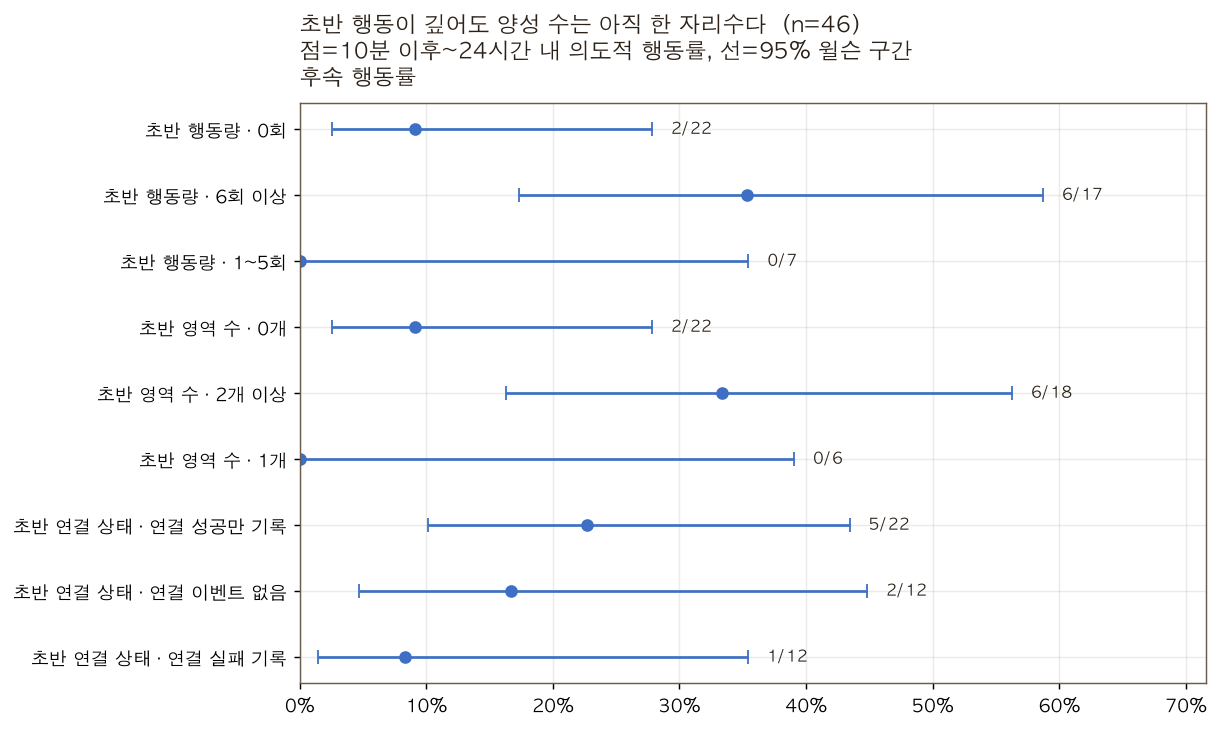

In [5]:
plot_axes = ['초반 행동량', '초반 영역 수', '초반 연결 상태']
plot = segments[segments.segment_axis.isin(plot_axes)].copy()
plot[['ci_low', 'ci_high']] = [wilson(int(k), int(n)) for k, n in zip(plot.later_active_devices, plot.devices)]
plot['label'] = plot.segment_axis + ' · ' + plot.segment_value
plot = plot.sort_values(['segment_axis', 'devices'])

fig, ax = R.new(
    '초반 행동이 깊어도 양성 수는 아직 한 자리수다',
    int(segments.query("segment_axis == '전체'").devices.iloc[0]),
    sub='점=10분 이후~24시간 내 의도적 행동률, 선=95% 윌슨 구간',
    ylab='후속 행동률',
    figsize=(9, 5.8),
)
y = range(len(plot))
ax.errorbar(
    plot.later_active_rate,
    list(y),
    xerr=[plot.later_active_rate - plot.ci_low, plot.ci_high - plot.later_active_rate],
    fmt='o',
    color=R.PALETTE[1],
    capsize=4,
)
ax.set_yticks(list(y), plot.label)
ax.set_xlim(0, min(1, max(plot.ci_high) * 1.22))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i, (_, row) in enumerate(plot.iterrows()):
    ax.text(row.ci_high + 0.015, i, f"{int(row.later_active_devices)}/{int(row.devices)}", va='center', fontsize=9)
chart_segment = R.save(fig, ax, 'g3_toss_segment_later_rate', zero_base=False)
print(R.check(chart_segment))
display(R.show(chart_segment))


## 5. 다음 모델링에 필요한 최소 조건

현재 후보 라벨은 “10분 이후 24시간 내 의도적 행동이 있었나”다. 게임 중 리텐션을 유지하고 퀘스트·즐길거리로 유도하는 로직으로 이어지려면, 라벨은 단순 후속 행동보다 **개입 가능한 다음 행동**에 가까워야 한다.

이번 숫자로 가능한 결론은 좁다. 첫 10분 행동이 6회 이상인 집단에서 후속 행동 6/17이 관측됐지만, 전체 양성이 8대뿐이다. `1~5회`의 0/7이나 낚시·바다 3/4 같은 값은 패턴 후보일 뿐 모델 피처로 확정할 수 없다.

G4로 넘어가기 전 필요한 조건:

1. 예측 목표를 하나로 고정한다. 후보는 `후속 의도적 행동`, `새 영역 첫 도달`, `퀘스트/교류 도달`, `다음 세션 재방문` 중 하나다.
2. 표본이 최소한 전체 100대 이상, 양성 20대 이상이 될 때까지는 모델 학습보다 베이스라인만 본다.
3. 내부 사용자·QA 기기 표식 커버리지를 확인한다. 표식이 없으면 심층 행동 상위 기기를 민감도 제외군으로 둔다.
4. 첫 10분 안에서 추천 가능한 상태 피처만 남긴다. 예: 초반 영역 수, 자연·채집 도달, 퀘스트·교류 도달, 연결 실패, 로그인 화면, 튜토리얼 진행. 이후 24시간 이벤트나 전체 첫날 총량은 피처로 쓰지 않는다.
5. G4는 다수 클래스와 단일 피처 베이스라인까지만 돌린다. G5 모델 학습은 별도 승인 뒤 진행한다.

## 6. 이 숫자로 말할 수 없는 것

- 이 라벨은 D1/D7 리텐션이 아니다. “24시간 내 한 번 더 행동했다”는 좁은 대리 지표다.
- 세그먼트별 차이는 대부분 한 자리수 분자다. 순위·인과·개인화 규칙으로 읽을 수 없다.
- `platform=toss` 표식 전에 떠난 사용자는 표본에 없다. 진입 실패를 포함한 전체 토스 유입 이탈률은 아니다.
- 연결 실패와 후속 행동의 관계는 순서와 재시도 흐름을 보지 않으면 원인으로 해석할 수 없다.
- 익명 기기 후보표는 같은 브라우저/기기 단위다. 사람 단위 리텐션으로 승격할 수 없다.

In [6]:
assumptions = {
    'analysis': 'g3-toss-segment-readiness-for-modeling',
    'date': '2026-09-15',
    'source': 'BigQuery GA4 daily export, 2026-09-04 through 2026-09-12 KST',
    'gate': 'G3 supplemental readiness audit',
    'decision_supported': 'Whether the Toss early/later candidate label is ready for G4 baselines.',
    'result': 'not_ready_for_model_training',
    'checks': {
        'device_rows': int(len(devices)),
        'candidate_positive_devices': int(devices.later_active.sum()),
        'candidate_negative_devices': int((~devices.later_active).sum()),
        'feature_boundary_violations': int(devices.feature_boundary_violations.sum()),
        'label_boundary_violations': int(devices.label_boundary_violations.sum()),
        'overall_flag': str(segments.query("segment_axis == '전체'").modeling_readiness_flag.iloc[0]),
    },
    'assumptions': [
        {
            'assumption': 'platform=toss identifies the relevant Toss webview cohort after the first recorded Toss event.',
            'confidence': 'medium',
            'impact_if_wrong': 'high',
            'validation': 'Cross-check against server-side session platform when available.',
            'result': 'open',
        },
        {
            'assumption': 'The 10-minute feature window contains only information available before intervention.',
            'confidence': 'high',
            'impact_if_wrong': 'critical',
            'validation': 'Boundary violation counts are zero.',
            'result': 'passed',
        },
        {
            'assumption': 'A 10m-to-24h deliberate action label is useful for quest/content guidance.',
            'confidence': 'low',
            'impact_if_wrong': 'critical',
            'validation': 'Needs user agreement on the business target before G4.',
            'result': 'candidate_only',
        },
        {
            'assumption': 'Marked beta_A/B devices are enough to remove testers.',
            'confidence': 'medium',
            'impact_if_wrong': 'high',
            'validation': 'Needs tester roster/device coverage or sensitivity exclusion of deep devices.',
            'result': 'open',
        },
    ],
}
(OUT / 'assumptions.json').write_text(json.dumps(assumptions, ensure_ascii=False, indent=2), encoding='utf-8')
display(Markdown('```json\n' + json.dumps(assumptions, ensure_ascii=False, indent=2) + '\n```'))


```json
{
  "analysis": "g3-toss-segment-readiness-for-modeling",
  "date": "2026-09-15",
  "source": "BigQuery GA4 daily export, 2026-09-04 through 2026-09-12 KST",
  "gate": "G3 supplemental readiness audit",
  "decision_supported": "Whether the Toss early/later candidate label is ready for G4 baselines.",
  "result": "not_ready_for_model_training",
  "checks": {
    "device_rows": 46,
    "candidate_positive_devices": 8,
    "candidate_negative_devices": 38,
    "feature_boundary_violations": 0,
    "label_boundary_violations": 0,
    "overall_flag": "minority<10"
  },
  "assumptions": [
    {
      "assumption": "platform=toss identifies the relevant Toss webview cohort after the first recorded Toss event.",
      "confidence": "medium",
      "impact_if_wrong": "high",
      "validation": "Cross-check against server-side session platform when available.",
      "result": "open"
    },
    {
      "assumption": "The 10-minute feature window contains only information available before intervention.",
      "confidence": "high",
      "impact_if_wrong": "critical",
      "validation": "Boundary violation counts are zero.",
      "result": "passed"
    },
    {
      "assumption": "A 10m-to-24h deliberate action label is useful for quest/content guidance.",
      "confidence": "low",
      "impact_if_wrong": "critical",
      "validation": "Needs user agreement on the business target before G4.",
      "result": "candidate_only"
    },
    {
      "assumption": "Marked beta_A/B devices are enough to remove testers.",
      "confidence": "medium",
      "impact_if_wrong": "high",
      "validation": "Needs tester roster/device coverage or sensitivity exclusion of deep devices.",
      "result": "open"
    }
  ]
}
```

## 7. 판정과 다음 확인

**G3 보강 판정:** 시간 경계와 재현 가능한 익명 후보표는 통과했다. 모델 학습은 보류한다. 전체 46대, 임시 양성 8대라 지금 학습하면 게임 중 리텐션 신호보다 몇몇 심층 기기와 날짜 꼬리를 외울 가능성이 크다.

**다음 게이트 후보:** 사용자와 예측 목표를 먼저 고른 뒤 G4 베이스라인으로 간다. 지금 가장 덜 위험한 목표 후보는 `10분 이후 24시간 내 퀘스트·교류 또는 새 영역 도달`처럼 실제로 게임 안에서 유도할 수 있는 행동이다. 단, 목표를 확정하기 전에는 이 후보를 전제로 다음 분석을 시작하지 않는다. 여기서 멈춘다.